In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("AirPassengers.csv")

In [3]:
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [4]:
df.describe()

,#Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [6]:
df["Month"] = pd.to_datetime(df['Month'])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Month        144 non-null    datetime64[ns]
 1   #Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


In [8]:
df.isnull().sum()

Month          0
#Passengers    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df

,Month,#Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


FIRST REQUIREMENT CONVERT DATE COLUMN TO INDEX

In [11]:
df.set_index("Month",inplace=True)

In [12]:
df

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


SECONF REQUIREMENT TO CHECK WETHER THE DATA IS STATIONARY OR NON-STATIONARY

<Axes: xlabel='Month'>

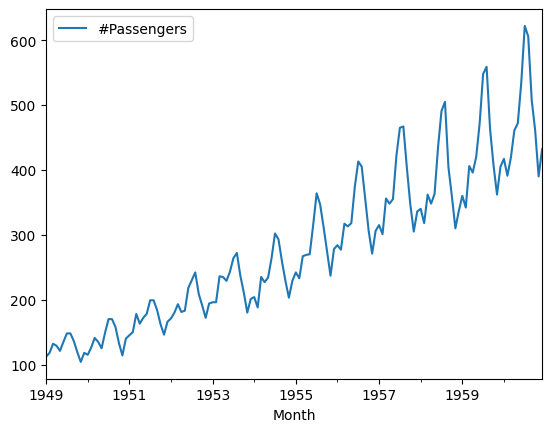

In [13]:
df.plot()

Figure(640x480)


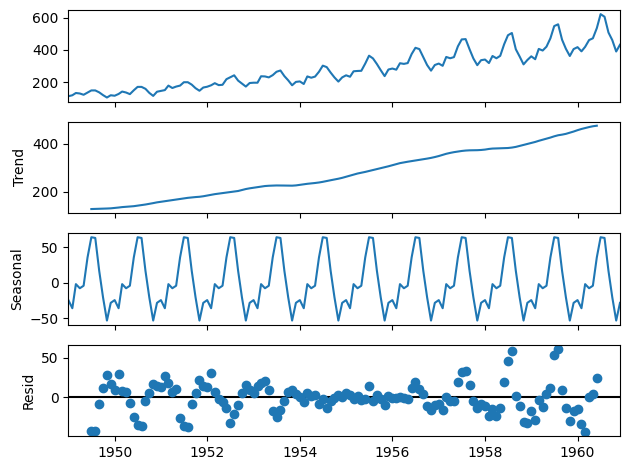

In [14]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposed = seasonal_decompose(df)
print(decomposed.plot())

In [15]:
from statsmodels.tsa.stattools import adfuller #Audmented Dickey Fuller Test
test_result = adfuller(df)

In [16]:
pval = test_result[1]
pval

np.float64(0.991880243437641)

In [17]:
if pval <.5:
    print("Data is stationary")
else:
    print("Data is not stationary")

Data is not stationary


IF DATA IS NON-STATIONARY CONVERT IT TO STATIONARY DATA

step1 lograthmic transformation

In [18]:
first_log = np.log(df)
first_log = first_log.dropna()
first_log

,#Passengers
Month,
1949-01-01,4.718499
1949-02-01,4.770685
1949-03-01,4.882802
1949-04-01,4.859812
1949-05-01,4.795791
...,...
1960-08-01,6.406880
1960-09-01,6.230481
1960-10-01,6.133398


Step2 rolling mean

In [19]:
mean_log = first_log.rolling(window=12).mean()  #we have 12 months in a year so window size is 12 it changes according to the data

In [20]:
mean_log.head(15)

,#Passengers
Month,
1949-01-01,NaN
1949-02-01,NaN
1949-03-01,NaN
1949-04-01,NaN
1949-05-01,NaN
1949-06-01,NaN
1949-07-01,NaN
1949-08-01,NaN
1949-09-01,NaN


step3 differencing

In [21]:
new_data = first_log - mean_log
new_data = new_data.dropna()
new_data.head(15)

,#Passengers
Month,
1949-12-01,-0.065494
1950-01-01,-0.093449
1950-02-01,-0.007566
1950-03-01,0.099416
1950-04-01,0.052142
1950-05-01,-0.027529
1950-06-01,0.139881
1950-07-01,0.260184
1950-08-01,0.248635


<Axes: xlabel='Month'>

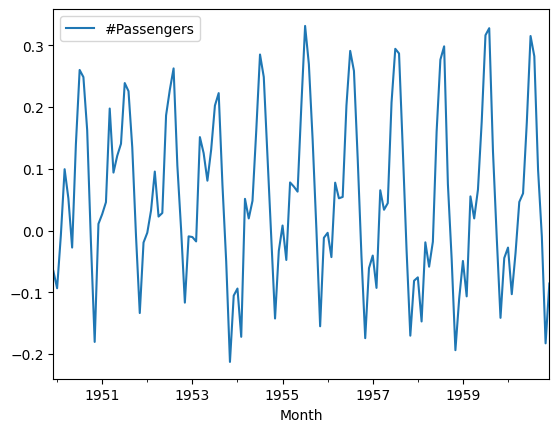

In [22]:
new_data.plot()

In [23]:
from statsmodels.tsa.stattools import adfuller
test_result = adfuller(new_data)

In [24]:
pval = test_result[1]
pval

np.float64(0.022234630001243157)

In [25]:
if pval <.5:
    print("Data is stationary")
else:
    print("Data is not stationary")

Data is stationary


In [26]:
train = new_data.iloc[0:120]["#Passengers"]
test = new_data.iloc[120:]["#Passengers"]

In [27]:
train

Month
1949-12-01   -0.065494
1950-01-01   -0.093449
1950-02-01   -0.007566
1950-03-01    0.099416
1950-04-01    0.052142
                ...   
1959-07-01    0.316430
1959-08-01    0.327838
1959-09-01    0.128057
1959-10-01   -0.011315
1959-11-01   -0.141406
Name: #Passengers, Length: 120, dtype: float64

In [28]:
test

Month
1959-12-01   -0.044481
1960-01-01   -0.027530
1960-02-01   -0.103067
1960-03-01   -0.036530
1960-04-01    0.046332
1960-05-01    0.060186
1960-06-01    0.175033
1960-07-01    0.315151
1960-08-01    0.282363
1960-09-01    0.098235
1960-10-01   -0.009230
1960-11-01   -0.182690
1960-12-01   -0.085789
Name: #Passengers, dtype: float64

 ARIMA -AutoRegressive Integrated Moving Average
 ARIMA - (p,d,q)

 p - order of lag , p= ?
 d - degree of differencing d=1
 q - order of moving average q= ?

...

p: How many past values you want to use for prediction.
d: How many times you need to subtract past values to make the data steady.
q: How many past errors you want to use to improve your predictions.

to find the optimal values of pdq

In [29]:
from sklearn import * 

In [30]:
from sklearn.metrics import mean_squared_error


In [32]:
from statsmodels.tsa.arima.model import ARIMA
A_model =  ARIMA(train,order=(5,0,4))

C:\Users\ayush\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ayush\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ayush\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [ ]:
A_model = A_model.fit()

C:\Users\ayush\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
new_data["ARIMA_prediction"] = A_model.predict( start=len(train) , end=len(train) + len(test) )

In [ ]:
new_data["ARIMA_prediction"]

Month
1949-12-01         NaN
1950-01-01         NaN
1950-02-01         NaN
1950-03-01         NaN
1950-04-01         NaN
                ...   
1960-08-01    0.232195
1960-09-01    0.141654
1960-10-01    0.030589
1960-11-01   -0.055403
1960-12-01   -0.113230
Name: ARIMA_prediction, Length: 133, dtype: float64

In [34]:
import itertools
p = range(0,7)
d = range(0,2)
q = range(0,7)

pdq = list(itertools.product(p,d,q))
rmse = []
order1 = []

for i in pdq:
    model = ARIMA(train,order = i)
    model_fit = model.fit()
    pred = model_fit.predict(start = len(train),end = len(train)+len(test)-1)
    error = np.sqrt(mean_squared_error(test,pred))  
    order1.append(i)
    rmse.append(error)

results = pd.DataFrame(index=order1,data=rmse,columns=["Rmse"])

C:\Users\ayush\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ayush\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ayush\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ayush\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\Local

In [35]:
results.sort_values(by="Rmse",ascending=True)

,Rmse
"(5, 0, 4)",0.061098
"(6, 0, 6)",0.068626
"(6, 1, 6)",0.069945
"(5, 0, 6)",0.071098
"(4, 1, 6)",0.071683
...,...
"(2, 1, 0)",0.217928
"(0, 1, 0)",0.228469
"(1, 1, 1)",0.240002
"(0, 1, 1)",0.252662


<Axes: xlabel='Month'>

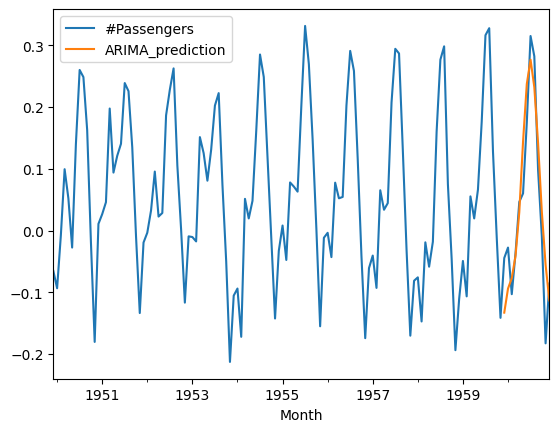

In [ ]:
new_data[["#Passengers","ARIMA_prediction"]].plot()

SARIMAX (Seasonal AutoRegressive Integrated Moving Average with eXogenous factors) is an advanced time series forecasting
model that extends the ARIMA model

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
model = SARIMAX(train,order=(5,0,4),seasonal_order=(5,0,4,12))  #here the fourth parameter is window size
model = model.fit()

C:\Users\ayush\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ayush\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ayush\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\ayush\AppData\Local\Packages\PythonSoftwareFoundation.Pyt

In [ ]:
new_data["s_predict"] = model.predict(start = len(train),end=len
(train)+len(test))

<Axes: xlabel='Month'>

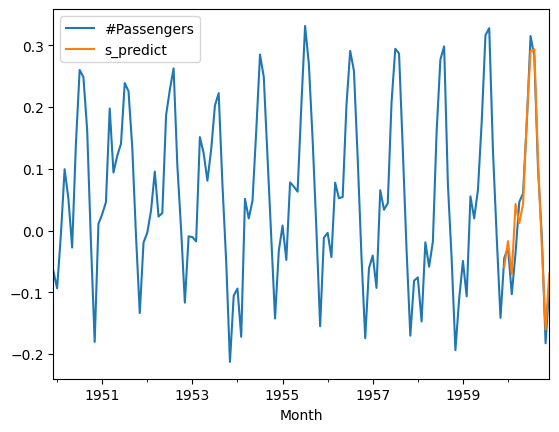

In [ ]:
new_data[["#Passengers","s_predict"]].plot()